In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zafarali27/house-price-prediction-dataset/House Price Prediction Dataset.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("/kaggle/input/datasets/zafarali27/house-price-prediction-dataset/House Price Prediction Dataset.csv")

In [4]:
df.head(3)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746


In [5]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [7]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [8]:
df.drop(columns=["Id"],inplace=True)

**NO OF HOUSE IN EACH LOCATION**

In [9]:

df["Location"].value_counts()

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

<Axes: ylabel='count'>

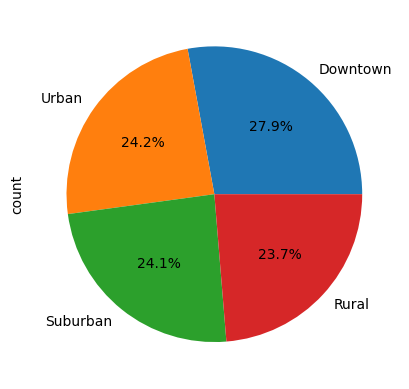

In [10]:
df["Location"].value_counts().plot(kind="pie",autopct="%.1f%%")

**Downtown Has Highest No of Houses.**

<Axes: xlabel='Price', ylabel='Area'>

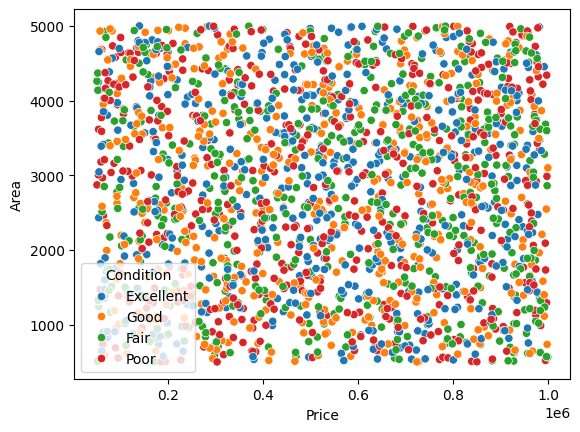

In [11]:
sns.scatterplot(data=df,x="Price",y="Area",hue="Condition")

*From Above Graph ,It is Clearly Shown That Every Type of House In term Of Area,Condition are Present in a Price Range.*

<Axes: xlabel='Location', ylabel='Price'>

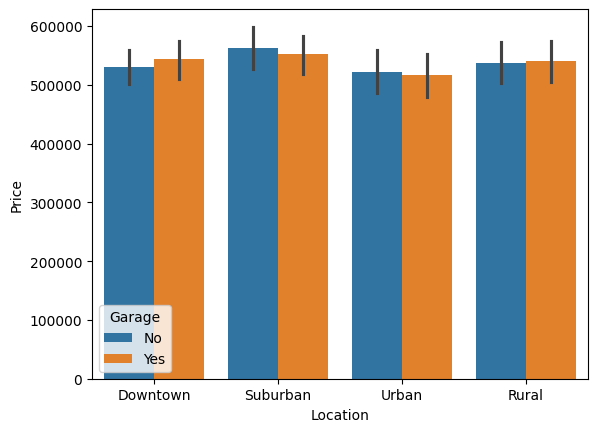

In [12]:
sns.barplot(data=df,x="Location",y="Price",hue="Garage")

*Almost Same Price For House Have Garage Or Not.*

In [13]:
df.head(2)

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998


In [14]:
df.groupby(df["Garage"])["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Garage,,,,,,,,
No,1038.0,536920.700385,278246.304279,50064.0,297586.50,542865.5,773735.75,999656.0
Yes,962.0,538492.747401,274596.636620,50005.0,305359.75,533877.0,787028.50,999453.0


{'whiskers': [<matplotlib.lines.Line2D at 0x7ac8c81f2f30>,
 'caps': [<matplotlib.lines.Line2D at 0x7ac8c81f3530>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ac8c81f2cc0>],
 'medians': [<matplotlib.lines.Line2D at 0x7ac8c81f3aa0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ac8c81ec050>],
 'means': [<matplotlib.lines.Line2D at 0x7ac8c81f3d70>]}

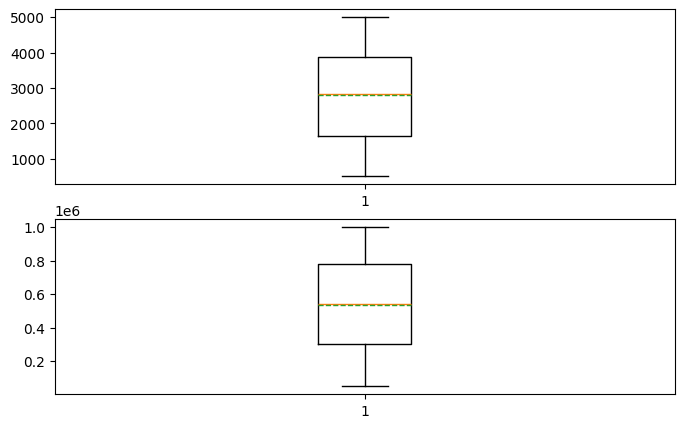

In [15]:
plt.figure(figsize=(8,5))

plt.subplot(2,1,1)
plt.boxplot(df["Area"],showmeans=True,meanline=True)

plt.subplot(2,1,2)
plt.boxplot(df["Price"],showmeans=True,meanline=True)

NO OUTLIER IN PRICE,AREA COLUMNS.

In [16]:
df["Condition"].value_counts()

Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64

/tmp/ipykernel_16/83332487.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:pink'` for the same effect.

  sns.countplot(data=df,x="Condition",hue="Location",color="pink",edgecolor="black")


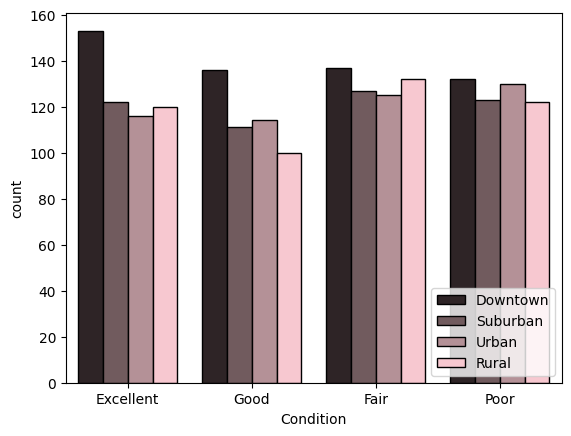

In [17]:
sns.countplot(data=df,x="Condition",hue="Location",color="pink",edgecolor="black")
plt.legend(loc="lower right")

*Downtown Has The Best Variety of House Whereas Rural Has the least.*

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=["Price"]),df["Price"],test_size=0.2,random_state=42)

In [19]:
X_train.sample(2)

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
496,4209,1,4,2,2020,Downtown,Poor,Yes
685,4096,1,4,1,1922,Downtown,Fair,Yes


In [20]:
from sklearn.preprocessing import OneHotEncoder
ohe_loc=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
ohe_Garage=OneHotEncoder(sparse_output=False,handle_unknown="ignore")

X_train_loc=ohe_loc.fit_transform(X_train[["Location"]])
X_train_Garage=ohe_Garage.fit_transform(X_train[["Garage"]])

X_test_loc=ohe_loc.transform(X_test[["Location"]])
X_test_Garage=ohe_Garage.transform(X_test[["Garage"]])

In [21]:
df["Condition"].unique()

array(['Excellent', 'Good', 'Fair', 'Poor'], dtype=object)

In [22]:
from sklearn.preprocessing import OrdinalEncoder
oe_con=OrdinalEncoder(categories=[["Poor","Fair","Good","Excellent"]])
X_train_con=oe_con.fit_transform(X_train[["Condition"]])
X_test_con=oe_con.transform(X_test[["Condition"]])

In [23]:
df.head(2)


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998


In [24]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_train_AY=ss.fit_transform(X_train[["Area","YearBuilt"]])
X_test_AY=ss.transform(X_test[["Area","YearBuilt"]])


In [25]:

X_train_rem=X_train.drop(columns=["Location","Condition","Garage","Area","YearBuilt"])
X_test_rem=X_test.drop(columns=["Location","Condition","Garage","Area","YearBuilt"])

In [26]:
X_train_tran=np.concatenate((X_train_AY,X_train_loc,X_train_Garage,X_train_con,X_train_rem),axis=1)
X_test_tran=np.concatenate((X_test_AY,X_test_loc,X_test_Garage,X_test_con,X_test_rem),axis=1)

In [27]:
X_train_tran.shape

(1600, 12)

**> MODEL SELECTION** 

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


M1=LinearRegression()
M2=RandomForestRegressor()
M3=XGBRegressor()

**BY LINEAR REGRESSION :-**

In [29]:
M1.fit(X_train_tran,y_train)
y_pred=M1.predict(X_test_tran)


In [30]:
from sklearn.metrics import mean_absolute_error
X=mean_absolute_error(y_test,y_pred)
X

243453.00113858172

**BY RANDOM FOREST REGRESSOR******

In [31]:
M2.fit(X_train_tran,y_train)
y_pred_f=M2.predict(X_test_tran)

In [32]:
from sklearn.metrics import mean_absolute_error
Y=mean_absolute_error(y_test,y_pred_f)
Y

253103.88600000003

**BY XGBRegressor**

In [33]:
M3.fit(X_train_tran,y_train)
y_pred_x=M3.predict(X_test_tran)

In [34]:
from sklearn.metrics import mean_absolute_error
Z=mean_absolute_error(y_test,y_pred_f)
Z

253103.88600000003

In [35]:
pd.DataFrame({"MODELS":["Linear_Regression","Random_Forest_Regressor","XGBRegressor"],"MEAN_ABSOLUTE_ERROR":[X,Y,Z]})

,MODELS,MEAN_ABSOLUTE_ERROR
0,Linear_Regression,243453.001139
1,Random_Forest_Regressor,253103.886000
2,XGBRegressor,253103.886000


**LINEAR RERESSION GIVE BEST PREDICTION**

In [36]:
import pickle
pickle.dump(M1,open("linear_regression.pkl","wb"))